# Aula Prática: Tratamento de Dados Não Estruturados

Nesta aula, vamos aprender a transformar dados "brutos" (texto e imagens) em formatos que modelos de Machine Learning conseguem processar.

---
## 1. Setup e Dependências
Primeiro, vamos instalar e importar as bibliotecas necessárias para NLP (Processamento de Linguagem Natural) e Processamento de Imagens.

In [1]:
%pip install pandas nltk matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 972.4 kB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from PIL import Image, ImageOps, ImageDraw
import matplotlib.pyplot as plt

# Fazendo o download de recursos necessários do NLTK

# NLTK (Natural Language Toolkit)?

O NLTK é uma das bibliotecas mais populares e completas do Python para trabalhar com 
dados de linguagem humana (NLP - Natural Language Processing). 

Pense nele como uma 'Caixa de Ferramentas' que contém algoritmos, corpora (grandes conjuntos 
de textos) e recursos léxicos para processar texto não estruturado.

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Setup concluído com sucesso!")

Setup concluído com sucesso!


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


# punkt
**O que é**: Um modelo de aprendizado de máquina pré-treinado.

**Função**: Tokenização Inteligente.

**Por que usar**: Se você separar um texto apenas por espaços, a palavra "U.S.A." 
viraria três partes ou manteria o ponto final. O 'punkt' entende abreviações, 
pontuações e sabe onde uma frase termina e outra começa.

# stopwords

**O que é**: Uma lista (dicionário) de palavras frequentes em vários idiomas.

**Função**: Filtragem de ruído.

**Por que usar**: Palavras como "de", "o", "a", "que", "em" aparecem muito, 
mas não ajudam a IA a entender o SENTIMENTO ou o ASSUNTO do texto.
Ao baixar esse pacote, você ganha acesso à lista 'portuguese' que contém 
centenas dessas palavras para remoção automática.

# punkt_tab

**O que é**: Tabelas de dados auxiliares para o tokenizador.

**Função**: Suporte técnico para o pacote punkt.

**Por que usar**: Em versões mais recentes do NLTK, o modelo 'punkt' 
precisa dessas tabelas de dados formatadas para organizar a separação 
de palavras de forma mais eficiente e rápida. Sem ele, o comando 
word_tokenize() pode gerar um erro de 'Resource not found'.

In [4]:
# O texto para o tratamento
texto_bruto = """
André Rebelo
PT
•
1 avaliação
28 de janeiro de 2026
Não é o mínimo frustrante que uma cadeia…
É no mínimo frustrante que uma cadeia global como o McDonald's, que se gaba de adaptar os seus produtos aos gostos locais e de inovar constantemente no menu, simplesmente ignore a presença do molho teriyaki. Num mundo onde se celebram sabores internacionais, a ausência deste clássico da cozinha asiática soa falta de ambição — ou pior, falta de atenção ao cliente.
O molho teriyaki é versátil, popular e já amplamente aceito pelo público europeu. Não é um sabor “exótico demais” nem arriscado: é doce, salgado, equilibrado e funcionaria perfeitamente com frango, hambúrgueres ou até nuggets. A verdade é que já vimos o McDonald's lançar produtos muito mais questionáveis ​​e temporários, enquanto deixa de fora um molho que poderia facilmente tornar-se favorito fixo.
Além disso, para uma marca que aposta tanto em edições especiais e experiências diferentes, não oferecer teriyaki passa a sensação de menu limitado e repetitivo. Falta ousádia. Falta ouvir quem quer algo além do óbvio ketchup–mostarda–barbecue.
"""

# 2. Tratamento de Texto (NLP)

Dados de texto costumam vir com ruídos: pontuação excessiva, letras maiúsculas/minúsculas misturadas e palavras que não agregam valor semântico (como "de", "o", "a").

Nosso objetivo é criar uma função que limpe uma string e a transforme em uma lista de **Tokens** significativos.


Uma análise simples baseada em palavras-chave (Léxico).

Poderiamos usar as bibliotecas TextBlob ou modelos de IA.

In [5]:
def analisar_sentimento(texto):
 
    palavras_negativas = ['frustrante', 'falta', 'ignore', 'pior', 'ausência', 'limitado', 'repetitivo']
    palavras_positivas = ['fantástico', 'bom', 'excelente', 'gostos', 'incrível']
    
    texto_minusculo = texto.lower()
    score = 0
    
    for p in palavras_negativas:
        if p in texto_minusculo:
            score -= 1
    for p in palavras_positivas:
        if p in texto_minusculo:
            score += 1
            
    return "Negativo" if score < 0 else "Positivo"

Verifica se o foco é no Produto ou no Atendimento.

In [6]:
def classificar_assunto(texto):
    """
    Verifica se o foco é no Produto ou no Atendimento.
    """
    termos_produto = ['molho', 'hambúrguer', 'nuggets', 'frango', 'menu', 'sabor', 'ketchup']
    termos_atendimento = ['atendimento', 'funcionário', 'demora', 'limpeza', 'balcão']
    
    texto_minusculo = texto.lower()
    
    # Contagem de ocorrências
    p_count = sum(1 for t in termos_produto if t in texto_minusculo)
    a_count = sum(1 for t in termos_atendimento if t in texto_minusculo)
    
    if p_count >= a_count and p_count > 0:
        return "Produto"
    elif a_count > p_count:
        return "Atendimento"
    else:
        return "Geral"

1. Extrair o Nome (geralmente a primeira linha não vazia)

O comando abaixo, limpa os espaços em branco, divide o texto linha por linha e captura apenas o conteúdo da primeira linha (índice 0).

É uma forma rápida de isolar o cabeçalho (neste caso, o nome do autor) de um bloco de texto.

    **.strip()** (A Limpeza): remove todos os espaços em branco, tabulações e quebras de linha (\n) que estejam no início e no fim do texto total.

    **.split('\n')** (A Quebra por Linhas): texto deixa de ser um bloco único e vira uma lista onde cada linha é um item: ['André Rebelo', 'PT', '•', '1 avaliação', ...]

    **[0]** (A Captura): o nome do autor é a primeira coisa que aparece no topo da review, a variável nome recebe apenas "André Rebelo".

In [7]:
nome = texto_bruto.strip().split('\n')[0]
print(nome)

André Rebelo


2. Extrair a Data (procurando o padrão 'dia de mês de ano')

        Usa Regex para localizar o padrão de data (dia, mês e ano) no meio do texto e extrai o valor encontrado, garantindo que o código não quebre caso a informação não exista.   

In [8]:
data_match = re.search(r'(\d{1,2} de \w+ de \d{4})', texto_bruto)
data = data_match.group(1) if data_match else "Data não encontrada"

print(data)

28 de janeiro de 2026


3. Limpar o corpo do comentário (removendo o cabeçalho)

Vamos pegar tudo que vem depois da data

In [9]:
corpo_texto = texto_bruto.split(data)[-1].strip()

print(corpo_texto)

Não é o mínimo frustrante que uma cadeia…
É no mínimo frustrante que uma cadeia global como o McDonald's, que se gaba de adaptar os seus produtos aos gostos locais e de inovar constantemente no menu, simplesmente ignore a presença do molho teriyaki. Num mundo onde se celebram sabores internacionais, a ausência deste clássico da cozinha asiática soa falta de ambição — ou pior, falta de atenção ao cliente.
O molho teriyaki é versátil, popular e já amplamente aceito pelo público europeu. Não é um sabor “exótico demais” nem arriscado: é doce, salgado, equilibrado e funcionaria perfeitamente com frango, hambúrgueres ou até nuggets. A verdade é que já vimos o McDonald's lançar produtos muito mais questionáveis ​​e temporários, enquanto deixa de fora um molho que poderia facilmente tornar-se favorito fixo.
Além disso, para uma marca que aposta tanto em edições especiais e experiências diferentes, não oferecer teriyaki passa a sensação de menu limitado e repetitivo. Falta ousádia. Falta ouvir 

4. Gerar as análises

In [10]:
sentimento = analisar_sentimento(corpo_texto)
assunto = classificar_assunto(corpo_texto)

print(sentimento, assunto)


Negativo Produto


Criando o dicionário de dados

In [11]:
dados_estruturados = {
    "Nome": [nome],
    "Data": [data],
    "Comentário": [corpo_texto[:100] + "..."], # Resumo para visualização
    "Sentimento": [sentimento],
    "Categoria": [assunto]
}

dados_estruturados

{'Nome': ['André Rebelo'],
 'Data': ['28 de janeiro de 2026'],
 'Comentário': ['Não é o mínimo frustrante que uma cadeia…\nÉ no mínimo frustrante que uma cadeia global como o McDona...'],
 'Sentimento': ['Negativo'],
 'Categoria': ['Produto']}

Transformando em DataFrame (Tabela)

In [12]:
df = pd.DataFrame(dados_estruturados)

df

,Nome,Data,Comentário,Sentimento,Categoria
0,André Rebelo,28 de janeiro de 2026,Não é o mínimo frustrante que uma cadeia…\nÉ n...,Negativo,Produto


Exibindo os resultados de forma organizada

In [13]:
print("--- RESULTADO DO PROCESSAMENTO ---")
print(df.to_string(index=False))

--- RESULTADO DO PROCESSAMENTO ---
        Nome                  Data                                                                                               Comentário Sentimento Categoria
André Rebelo 28 de janeiro de 2026 Não é o mínimo frustrante que uma cadeia…\nÉ no mínimo frustrante que uma cadeia global como o McDona...   Negativo   Produto


Exemplo de como acessar apenas as colunas solicitadas

In [14]:
print("\n--- COLUNAS ESPECÍFICAS ---")
print(df[['Nome', 'Data', 'Sentimento', 'Categoria']])


--- COLUNAS ESPECÍFICAS ---
           Nome                   Data Sentimento Categoria
0  André Rebelo  28 de janeiro de 2026   Negativo   Produto


### Exemplo de tratamento de Texto - Dados da Parte Teórica

In [15]:
texto_exemplo = """
O aprendizado de Máquina (Machine Learning) é FANTÁSTICO!!! 
Estamos tratando dados NÃO ESTRUTURADOS hoje, dia 15/10/2023.
"""

In [16]:
def pipeline_limpeza(texto):
    # 1. Converter tudo para minúsculo
    texto = texto.lower()
    
    # 2. Remover pontuação e números usando Expressões Regulares (Regex)
    # Mantemos apenas letras e espaços
    texto = re.sub(r'[^a-zA-Záàâãéèêíïóôõöúç\s]', '', texto)
    
    # 3. Tokenização (dividir a frase em palavras individuais)
    tokens = word_tokenize(texto)
    
    # 4. Remoção de Stopwords (palavras comuns que não trazem significado ao modelo)
    stop_words = set(stopwords.words('portuguese'))
    tokens_limpos = [w for w in tokens if w not in stop_words]
    
    return tokens_limpos

# Testando a função

In [17]:
print("--- Texto Original ---")
print(texto_exemplo.strip())
print("\n--- Resultado Processado (Tokens) ---")
print(pipeline_limpeza(texto_exemplo))

--- Texto Original ---
O aprendizado de Máquina (Machine Learning) é FANTÁSTICO!!! 
Estamos tratando dados NÃO ESTRUTURADOS hoje, dia 15/10/2023.

--- Resultado Processado (Tokens) ---


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/caioacayabafurtado/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.13/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.13/share/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.13/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


# 3. Tratamento de Imagens

Diferente do texto, imagens são matrizes de pixels. Para redes neurais, precisamos que todas as imagens tenham o **mesmo tamanho** e, muitas vezes, convertê-las para **escala de cinza** para reduzir a complexidade.

# NOTAS: #
1. Ruído: Se a foto estiver tremida ou com sombra, o OCR falha. O pré-processamento é vital.
2. Layout: Contas de energia mudam o layout. Em empresas, usamos 'Templates' para dizer onde
   cada dado costuma ficar na imagem.
3. Bibliotecas: No VS Code, o aluno precisará de: **pip install pytesseract pillow pandas**

   Além de instalar o executável do Tesseract no Windows/Linux.

In [ ]:
%pip install PyMuPDF

Usando o Jupyter Notebook (ou Jupyter Lab), podemos ter um erro quando rodarmos os imports

Esse erro é o sinal mais clássico de que o pip instalou a biblioteca em um ambiente do Python, mas o seu Notebook está rodando em outro ambiente completamente diferente.

Isso acontece muito quando temos mais de uma versão do Python instalada ou quando usamos ambientes virtuais.

Vamos resolver forçando a instalação direto de dentro do Notebook.

A Solução Definitiva
Crie uma nova célula no topo do seu Notebook, cole o código abaixo e execute:

import sys

!{sys.executable} -m pip uninstall PyMuPDF fitz -y

!{sys.executable} -m pip install PyMuPDF


# Importando as Bibliotecas e Carregando o arquivo PDF

In [ ]:
import fitz  # Importa o PyMuPDF
import re
import pandas as pd
from IPython.display import Image, display

# 1. Carregar o arquivo PDF
documento = fitz.open("conta_luz_enel_ficticia.pdf")

# Tratamento do PDF para PNG - Renderização e Converção para PNG

**Renderização (get_pixmap)**: Transforma as coordenadas matemáticas em uma matriz de pontos (pixels). É como se estivessemos "tirando uma foto" da página do documento para que ela possa ser tratada como um objeto visual.

**Formato PNG (tobytes("png"))**: Ao converter o mapa de pixels para PNG, estamos usando um formato universal que qualquer navegador entende perfeitamente. O PNG é um formato "lossless" (sem perda de qualidade), o que garante que os textos pequenos da conta de luz (como o CPF ou o Valor Total) continuem legíveis na tela.

Manipulação em Memória (Sem arquivos temporários)
Note que usamos pix.tobytes("png") em vez de salvar um arquivo no disco (como pix.save("foto.png")).

Eficiência: Isso cria um objeto de bytes diretamente na memória RAM.

Limpeza: Isso evita que a pasta do seu projeto fique cheia de "lixo" (imagens temporárias de cada página que você quis visualizar). 

O comando display(Image(data=...)) pega esses bytes e injeta diretamente no HTML do seu Notebook.

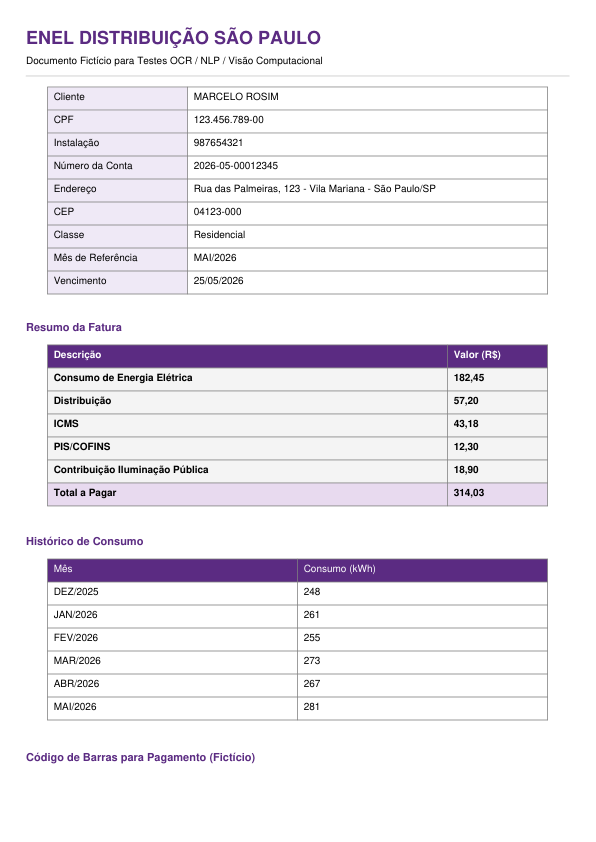

In [ ]:
# 1. Seleciona a primeira página
pagina = documento[0]

# 2. Renderiza a página como uma imagem
pix = pagina.get_pixmap()

# 3. Converte a imagem para o formato PNG em memória
imagem_bytes = pix.tobytes("png")

# 4. Exibe a imagem diretamente no Jupyter Notebook (Sem a vírgula no final!)
display(Image(data=imagem_bytes))

## Extrair os Textos

Objetivo é transformar o conteúdo visual do PDF em uma variável de texto (String) para que possamos realizar buscas e filtros

**pagina.get_text()**: Este método "lê" a camada de texto da página atual.

In [ ]:
# 2. Extrair o texto de todas as páginas
texto_completo = ""
for pagina in documento:
    texto_completo += pagina.get_text()

print(texto_completo)

ENEL DISTRIBUIÇÃO SÃO PAULO
Documento Fictício para Testes OCR / NLP / Visão Computacional
Cliente
MARCELO ROSIM
CPF
123.456.789-00
Instalação
987654321
Número da Conta
2026-05-00012345
Endereço
Rua das Palmeiras, 123 - Vila Mariana - São Paulo/SP
CEP
04123-000
Classe
Residencial
Mês de Referência
MAI/2026
Vencimento
25/05/2026
Resumo da Fatura
Descrição
Valor (R$)
Consumo de Energia Elétrica
182,45
Distribuição
57,20
ICMS
43,18
PIS/COFINS
12,30
Contribuição Iluminação Pública
18,90
Total a Pagar
314,03
Histórico de Consumo
Mês
Consumo (kWh)
DEZ/2025
248
JAN/2026
261
FEV/2026
255
MAR/2026
273
ABR/2026
267
MAI/2026
281
Código de Barras para Pagamento (Fictício)
83610000003 1 14030048100 5 987654321000 1 20260525000 2
Observações:
• Este documento é totalmente fictício e foi criado exclusivamente para testes de OCR, NLP e Visão Computacional.
• Nenhum dado presente nesta conta é real.
• Layout otimizado para leitura automatizada em Python utilizando Tesseract OCR, OpenCV ou bibliotecas s

## Mapeamento com Expressões Regulares (Regex)

Nesta etapa, estamos definindo as "regras de busca" para que o Python saiba exatamente o que extrair do texto bruto.

Estamos criando um **Dicionário de Padrões**. Cada chave (ex: "cliente") está associada a uma Expressão Regular (Regex) projetada para localizar um dado específico dentro da massa de texto da conta de luz.



**Transformação de Dados**: O texto extraído do PDF é "sujo" e desestruturado. O Regex funciona como um filtro de precisão que isola apenas a informação útil (o valor) do rótulo (o label).

**Escalabilidade**: Uma vez definido o padrão, o script pode processar centenas de contas de luz instantaneamente, desde que sigam a mesma lógica de layout

**Tratamento de Quebras de Linha**: O uso de [\s\n]+ nos padrões é vital porque, em arquivos PDF, o valor pode estar ao lado ou na linha abaixo do título. Esse comando diz ao Python: "Procure o título e pule quantos espaços ou quebras de linha forem necessários até encontrar o dado".

In [ ]:
# --- DEFINIÇÃO DOS PADRÕES DE BUSCA (REGEX) ---
# Utilizamos o sinal de + para pular quebras de linha ou espaços entre o label e o valor
padroes = {
    "empresa": r"(ENEL DISTRIBUIÇÃO SÃO PAULO)",
    "cliente": r"Cliente[\s\n]+([A-Z\s]+?)\n",
    "cpf": r"CPF[\s\n]+([\d\.-]+)",
    "instalacao": r"Instalação[\s\n]+(\d+)",
    "numero_da_conta": r"Número da Conta[\s\n]+([\d-]+)",
    "endereco": r"Endereço[\s\n]+(.+?)\n",
    "cep": r"CEP[\s\n]+(\d{5}-\d{3})",
    "classe": r"Classe[\s\n]+(\w+)",
    "mes_de_referencia": r"Mês de Referência[\s\n]+([A-Z]{3}/\d{4})",
    "vencimento": r"Vencimento[\s\n]+(\d{2}/\d{2}/\d{4})",
    "total_a_pagar": r"Total a Pagar[\s\n]+([\d,.]+)"
}

## Execução da Extração - Loop de Captura

Nesta etapa, o Python percorre nosso dicionário de padrões e varre o texto do PDF em busca das informações. Estamos automatizando a busca individual de cada campo (cliente, CPF, total, etc.) dentro do texto bruto

**Iteração Eficiente (for)**: Em vez de escrever 11 códigos diferentes para 11 campos, usamos um laço que aplica cada regra de busca automaticamente.

**Tratamento de Erros (if/else)**: Nem todo PDF é perfeito. O código verifica se a informação foi encontrada (if resultado). Se não encontrar (campo ausente ou erro de leitura), ele preenche com None (vazio), evitando que o programa trave

**Refinamento (.group(1).strip())**:

        O group(1) isola apenas o dado que está dentro dos parênteses do nosso Regex (excluindo o título como "CPF:").

        O strip() remove espaços em branco inúteis no início ou fim do texto, garantindo dados limpos para a análise.

In [ ]:
# --- EXTRAÇÃO DOS DADOS ---
dados_extraidos = {}

for coluna, regex in padroes.items():
    resultado = re.search(regex, texto_completo, re.IGNORECASE | re.MULTILINE)
    if resultado:
        # Pega o conteúdo do primeiro grupo de parênteses e limpa espaços extras
        dados_extraidos[coluna] = resultado.group(1).strip()
    else:
        dados_extraidos[coluna] = None

print(dados_extraidos)

{'empresa': 'ENEL DISTRIBUIÇÃO SÃO PAULO', 'cliente': 'MARCELO ROSIM', 'cpf': '123.456.789-00', 'instalacao': '987654321', 'numero_da_conta': '2026-05-00012345', 'endereco': 'Rua das Palmeiras, 123 - Vila Mariana - São Paulo/SP', 'cep': '04123-000', 'classe': 'Residencial', 'mes_de_referencia': 'MAI/2026', 'vencimento': '25/05/2026', 'total_a_pagar': '314,03'}


# Geração do Dataframe


A partir do dataframe, podemos aplicar a Limpeza, Padronização e Enriquecimento destes dados

In [ ]:
# --- CRIAÇÃO DO DATAFRAME ---
df = pd.DataFrame([dados_extraidos])

# Exibir o resultado final
display(df)

,empresa,cliente,cpf,instalacao,numero_da_conta,endereco,cep,classe,mes_de_referencia,vencimento,total_a_pagar
0,ENEL DISTRIBUIÇÃO SÃO PAULO,MARCELO ROSIM,123.456.789-00,987654321,2026-05-00012345,"Rua das Palmeiras, 123 - Vila Mariana - São Pa...",04123-000,Residencial,MAI/2026,25/05/2026,"314,03"


# Saída

Geração de um arquivo CSV, ou poderiamos estar inserindo diretamente na base de dados....

Bronze : local do nosso arquivo PDF original
Silver : local onde nossos dados tratados estariam disponíveis para uso, poderiamos tem um arquivo Parquet, particionado por ano e mês da leitura, e ir adicionado linhas conforme a leitura que iriamos fazendo

**ETL Reversa** a partir do arquivo parquet poderíamos atualizar nossa base de dados...Oracle, SQLServer, MySQL,....

In [ ]:
# Salvar os dados tratados em um CSV
df.to_csv("conta_luz.csv", index=False)